# RecipeNLG Exploration

In [1]:
import os 
os.chdir("/Users/lennischlenker/Documents/Projekte/RecipeLLM/")

In [2]:
os.getcwd()

'/Users/lennischlenker/Documents/Projekte/RecipeLLM'

In [ ]:
from scripts.data_generation_config import ORIG_DATASET_PATH, CLEANED_DATASET_PATH
import polars as pl 
from scripts.prepare_dataset import format_links, extract_websites, compute_link_hashes, build_responses, compute_dataset_split
import matplotlib.pyplot as plt
import seaborn as sns

Here, we prepare the dataframe for further processing. This includes the following steps: 

1. Formatting the links: To reliably identify the website part of the link, we prepend "www." to each link if necessary
2. Extracting the website: In order to analyze, where our recipes come from and thus, how HTML structures (assuming every recipe from the same website has mostly the same HTML structure) are distributed, we extract the domains using regex. 
3. Building response strings: The model is later expected to produce them, given the HTML as a user prompt. 
4. Compute link hashes: Since our scraping script stores the html files by hashing the link it downloaded them from, we need to compute the exact same hashes based on the links in order to load the HTML corresponding to our generated responses. 
5. Generate dataset split: To split the dataset into training and evaluation set, we analyze the website distributions in order to take around 10% as an evaluation set. 

In [12]:
df = pl.read_csv(ORIG_DATASET_PATH)

df = df.lazy()

df = format_links(df)
df = extract_websites(df)

df = build_responses(df)
df = compute_link_hashes(df)

df = df.select(
    pl.col("website"), 
    pl.col("hash"), 
    pl.col("response")
)

df = df.collect()

training, eval = compute_dataset_split(df)

Now it's time to take a look at the website distributions of both datasets. These determine how well our model generalizes / overfits on the dataset. If only one website provided most of the input HTMLs, we assume them to have the same structure and using the dataset as-is would risk the model overfitting to the over-represented structure of that one website. 

In [30]:
def get_websites_distribution(df): 

    website_groups = df.group_by("website").len()

    """
    website_groups = website_groups.with_columns(
        (pl.col("len") / len(df)).alias("frequency")
    )
    """

    fig, ax = plt.subplots()

    sns.barplot(data=website_groups, x="website", y="len", ax=ax)

    plt.xticks(rotation=90)
    plt.show()

    return website_groups

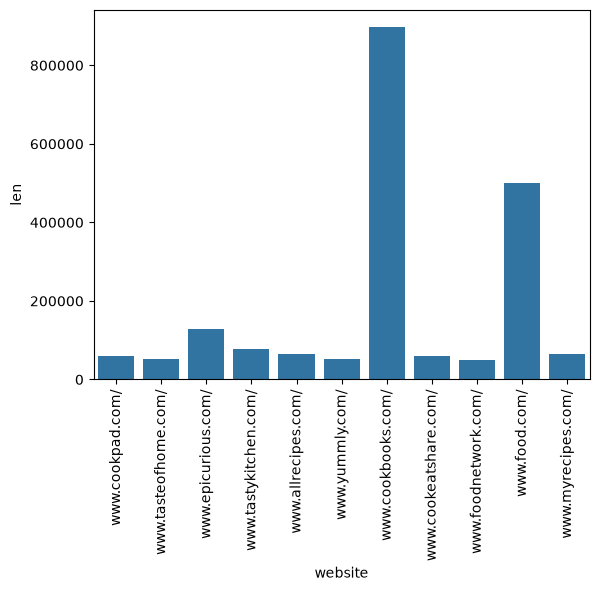

Minimum sample size per website in training: 49443


In [33]:
training_websites = get_websites_distribution(training)
training_min_sample_size = training_websites['len'].min()
print(f"Minimum sample size per website in training: {training_min_sample_size}")

As we can see, we are dealing with the exact scenario described above. `www.cookbooks.com` provides the vast majority of recipes. 

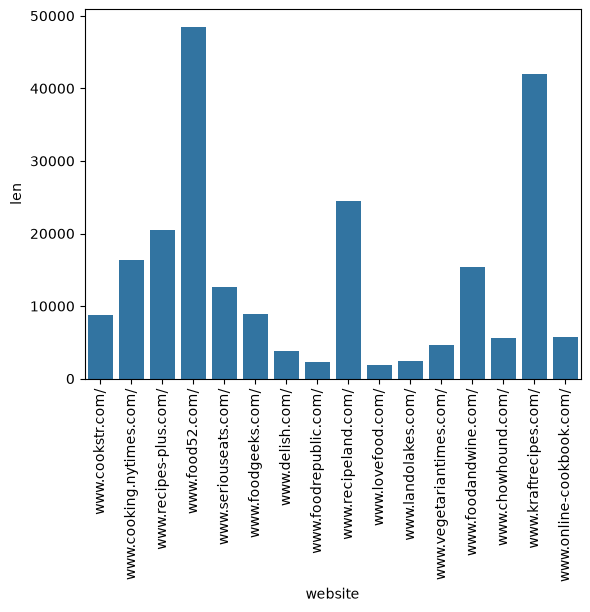

Minimum sample size per website in training: 1930


In [37]:
eval_websites = get_websites_distribution(eval)
eval_min_sample_size = eval_websites['len'].min()
print(f"Minimum sample size per website in training: {eval_min_sample_size}")

A similar problem can be shown for the evaluation dataset. `www.food52.com` and `www.kraftrecipes.com` dominate with 40K - 50K recipes, meanwhile most other websites barely provide 10K recipes. Therefore, we must find some method to uniformly sample from websites in order to avoid overfitting on one. For this, we determine the smallest sample size by website for both datasets and sample that exact number from each website, creating a new, smaller and uniformly distributed dataset.  

In [38]:
def sample_by_website(df, n): 
    df = df.partition_by("website")
    partitions = [p.sample(n) for p in df]
    df = pl.concat(partitions, how='vertical')
    return df 

Let's take a look at the new distributions. 

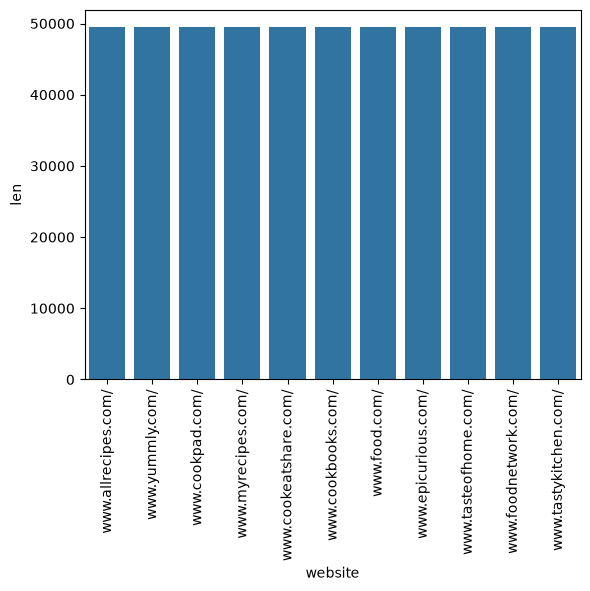

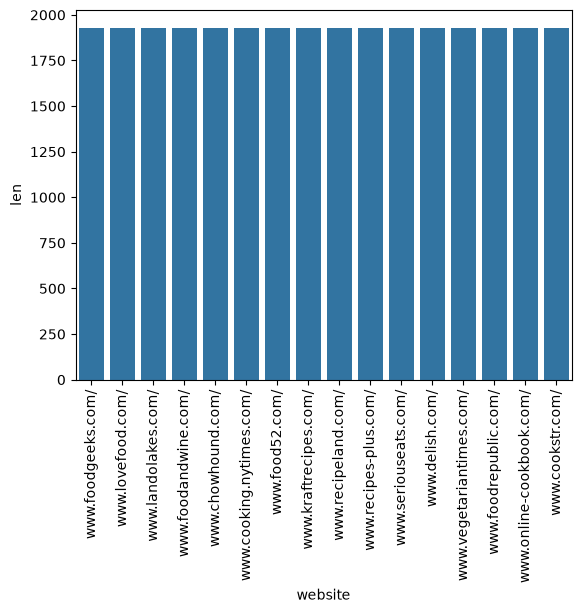

In [39]:
training = sample_by_website(training, training_min_sample_size)
_ = get_websites_distribution(training)
eval = sample_by_website(eval, eval_min_sample_size)
_ = get_websites_distribution(eval)

However, this also means that we reduce the eval sample to training sample ratio: 

In [ ]:
# reduced from ~10% eval to ~6% eval 
print(f"New ratio: {len(eval) / len(training)}")
print(f"Previous number of samples: {len(df)}")
print(f"Current number of samples: {len(training) + len(eval)}")
print(f"Thus, we reduced the dataset by {len(df) - (len(training) + len(eval))} samples")

New ratio: 0.056777961031343714
Previous number of samples: 2231142
Current number of samples: 574753
Thus, we reduced the dataset by 1656389 samples


6% is still a valid ratio and around 570K samples are enough to fine-tune an LLM for our use-case. This also comes in handy, as the scraped dataset of >2M HTML files would weigh more than 200GB, which is hard to uplaod to colab. Let's stack the dataframes back together to make them ready for HTML scraping.  

In [ ]:
training = training.with_columns(
    pl.lit(True).alias("train")
)
eval = eval.with_columns(
    pl.lit(False).alias("train")
)

training = training.vstack(eval)
training.write_parquet(CLEANED_DATASET_PATH)

# HTML Structure Exploration

Let's take a look at how big scraped HTML are in terms of context size of the LLM: 

In [ ]:
from scripts.convert_htmls_to_parquet import load_file
from training_config import MODEL_NAME
from os import listdir
from pathlib import Path
from itertools import islice, batched
from concurrent.futures import ThreadPoolExecutor
from statistics import mean, median

HTML_CACHE_DIR = "./data/raw/htmls/"


def first_n_files(directory, n):
    p = Path(directory)
    # filter to files only (skip subdirectories)
    files = (f for f in p.iterdir() if f.is_file())
    return list(islice(files, n))

Let's load the first 500 files of the HTML directory and check the statistics

In [63]:
from transformers import AutoTokenizer

nums_tokens = []
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
i = 1

with ThreadPoolExecutor(max_workers=10) as pool: 
    for batch in batched(first_n_files(HTML_CACHE_DIR, 500), 100): 
        results = list(pool.map(load_file, batch))
        tokenized_htmls = tokenizer(results)        
        nums_tokens += list(map(lambda x: len(x), tokenized_htmls["input_ids"]))


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (369559 > 131072). Running this sequence through the model will result in indexing errors


In [64]:
max_tokens = max(nums_tokens)
mean_tokens = mean(nums_tokens)
median_tokens = median(nums_tokens)

print(f"Maximum number of tokens in prompt: {max_tokens}")
print(f"Average number of tokens in prompt: {mean_tokens}")
print(f"Median number of tokens in prompt: {median_tokens}")

Maximum number of tokens in prompt: 552290
Average number of tokens in prompt: 161537.45
Median number of tokens in prompt: 114969.0


Let's take a look at the memory requirements (in bytes) for these numbers: 

In [ ]:
def compute_memory_requirement(n): 
    # self-attention requires roughly square(input_tokens) many weights
    # since we load the model in fp16, each weight takes up 2 bytes 
    return n**2 * 2 

# TODO: Wrong computation, since attention weight matrices are not simply stored in memory. Check out how Qwen2.5 1.5B does it. 

print(f"Memory requirement for the largest file: {compute_memory_requirement(max_tokens) / 1_000_000_000}GB")
print(f"Memory requirements for the average file: {compute_memory_requirement(mean_tokens) / 1_000_000_000}GB")
print(f"Memory requirements for the median file: {compute_memory_requirement(median_tokens) / 1_000_000_000}GB")

Memory requirement for the largest file: 610.0484882GB
Memory requirements for the average file: 52.18869550500501GB
Memory requirements for the median file: 26.435741922GB


Since we are working with a Nvidia T4 GPU in Colab (around 15GB VRAM and 12GB SysRAM), this isn't even close to fitting. 